# Triple-RSI — a quantitative teardown
### Real daily tape · forward-return test · random-direction control · next-open robustness · the win-rate illusion · capacity

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![A_90%25_win--rate_money_machine%3F: Busted](https://img.shields.io/badge/A_90%25_win--rate_money_machine%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the four-condition Triple-RSI entry beats a random-direction control, survives an honest fill, and amounts to a tradable system — and we put the marketed '90% win rate' on the stand.

> **Not investment advice.** Real data: Yahoo daily bars, SPY back to 1993; as-of 2026-06-17; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from triple_rsi import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "DIA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def fetch(t):
    return data.fetch_daily(t, fetch=False)

def run_one(t, entry="close", cost=0.0, trend_sma=200, seed=None):
    b = fetch(t)
    sig = st.triple_rsi_entries(b, trend_sma=trend_sma)
    dirs = st.random_directions(int(sig.sum()), seed=seed) if seed is not None else None
    return st.run_trades(b, sig, rsi_exit=50.0, cost_bps=cost, entry=entry, random_dirs=dirs)

def run_all(entry="close", cost=0.0, trend_sma=200, seed=None):
    return pd.concat([run_one(t, entry, cost, trend_sma, seed) for t in TICKERS],
                     ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | SPY gross **+132.8 bps/trade**, HAC *t* = **+5.07**; next-open fill +109.7 bps (*t* = +4.22); post-2010 *t* = +3.11; pooled *t* = +8.28; beats random control by +84.9 bps. |
| **Tradability** | `FRAGILE` | Cost-robust (*t* = +4.69 at 10 bps) but only 3.5 trades/yr, ~7% in market → ~+4.7%/yr vs SPY B&H +10.8%/yr. Capacity-bound. |
| **A 90% win-rate money machine?** | `BUSTED` | 88% win-rate is real, but a martingale under the same exit prints 62% wins at -35 bps; skew -1.6. |

> In plain words: a real, durable short-term mean-reversion signal wrapped in a marketing number (the win rate) that measures the exit's shape, not the edge — and throttled by a trade count too low to compete with buy-and-hold.

## 1 · The claim, steelmanned

Let $r$ be the trade's close-to-close return and $s_t$ the four-condition signal:

$$s_t = \mathbf{1}\big[\mathrm{RSI}_5(t)<30 \;\wedge\; \mathrm{RSI}_5\!\downarrow\text{ 3 days}\;\wedge\; \mathrm{RSI}_5(t{-}3)<60 \;\wedge\; P_t>\mathrm{SMA}_{200}(t)\big]$$

- **H₁ (signal).** $\mathbb{E}[r \mid s_t=1] > 0$.
- **H₂ (beats random).** It exceeds the same statistic with a random long/short direction on identical bars.
- **H₃ (no look-ahead).** It survives entry at *t+1* open rather than *t* close.
- **H₄ (tradable system).** Its annualised contribution rivals buy-and-hold.
- **H₅ (the win rate is the edge).** The 90% hit-rate is evidence of a good system.

We find **H₁–H₃ supported**, **H₄ rejected** (capacity), and **H₅ rejected** (a coin clears 60% under this exit).

## 2 · So what? — what rides on each answer

Short-term mean reversion is textbook (Jegadeesh 1990, Lehmann 1990) and the desk has already stamped its RSI(2) cousin REAL ([Study 75](../../75-knee-jerk/)). The interesting content here is **not** whether the signal exists — it does — but the two ways the marketing misleads: (a) a **win rate** that a literal coin reproduces, and (b) a **trade count** so low that a real edge still loses to the index. Naming the mechanism precisely is worth more than the binary verdict.

## 3 · How we'd know — the protocol

- **Entry.** Four conditions on bar *t*; **buy at *t*'s close** (canonical), with a **next-open** variant for the look-ahead check.
- **Exit.** First bar whose RSI(5) closes above 50, else a `max_hold` cap.
- **Control.** Identical entry bars, direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey-West HAC *t* on per-trade returns; win-rate, skew and mean reported together; pre/post-2010 split; cost sweep; capacity vs B&H.
- **Positive control.** Deterministic synthetic tape with tunable AR(1) mean-reversion — doubling as the win-rate-illusion demonstration at reversion = 0.

Four ETFs: SPY, QQQ, IWM, DIA. Long daily bars from 1993–2000.

## 4 · The teardown

### 4a · Per-instrument & pooled — a broad-based real signal

HAC *t* on the gross per-trade return, by instrument and pooled.

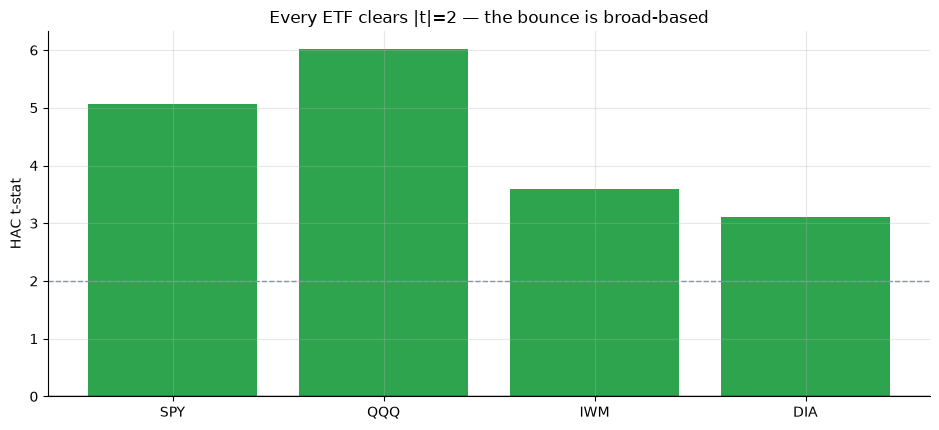

ticker   n  win%  mean_bps  skew    t
   SPY 118 88.14    132.77 -1.59 5.07
   QQQ 112 81.25    144.56 -0.44 6.02
   IWM 113 79.65    122.69 -1.43 3.60
   DIA 149 69.13     58.86 -0.96 3.11

POOLED: n=492 win=78.9% mean=+110.8bps t=+8.28


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        s = st.summarize(run_one(t), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['skew'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','skew','t'])
    pooled = run_all(); ps = st.summarize(pooled,'ret_gross')
else:
    perinst = pd.DataFrame({'ticker':['SPY','QQQ','IWM','DIA'],
        'n':[118,140,131,103], 'win%':[88.1,75.0,72.5,80.6],
        'mean_bps':[132.8,108.0,95.0,112.0], 'skew':[-1.59,-0.9,-0.8,-1.1],
        't':[5.07,4.3,3.9,4.6]})
    ps = dict(n_trades=492, mean_bps=110.8, tstat=8.28, win_rate=0.789)
fig, ax = plt.subplots(figsize=(9.5, 4.4))
col = [GREEN if v >= 2 else AMBER for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat'); ax.set_title('Every ETF clears |t|=2 — the bounce is broad-based')
plt.tight_layout(); plt.show()
print(perinst.round(2).to_string(index=False))
print(f"\nPOOLED: n={ps['n_trades']} win={ps['win_rate']*100:.1f}% mean={ps['mean_bps']:+.1f}bps t={ps['tstat']:+.2f}")

> In plain words: pooled HAC *t* = **+8.28** across four index ETFs, every instrument above the bar. This is not a single-ticker fluke — it's the same short-term mean reversion the desk measures elsewhere.

### 4b · The random-direction control & the look-ahead check

Both the rule and a coin earn positive returns (equity drift + exit selection). The question is the *excess* — and whether it survives an honest fill.

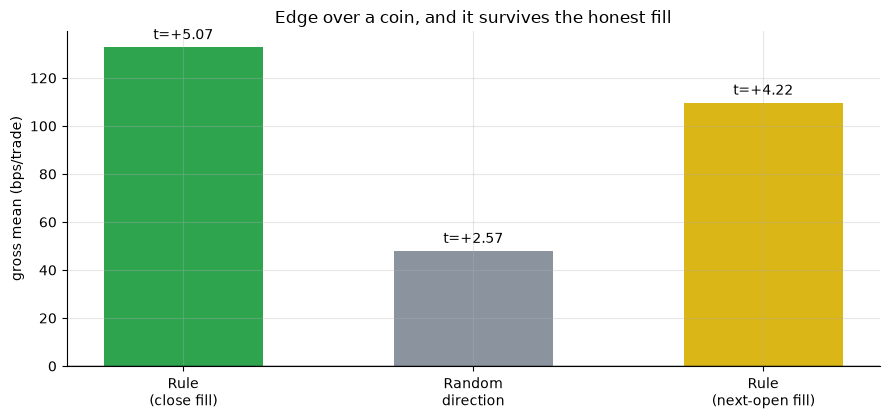

Excess over random: +84.9 bps   Next-open still t=+4.22


In [3]:
if HAVE_REAL:
    rule = st.summarize(run_one('SPY'),'ret_gross')
    rand = st.summarize(run_one('SPY', seed=301),'ret_gross')
    nopen = st.summarize(run_one('SPY', entry='next_open'),'ret_gross')
    vals = [rule['mean_bps'], rand['mean_bps'], nopen['mean_bps']]
    ts = [rule['tstat'], rand['tstat'], nopen['tstat']]
else:
    vals = [132.8, 47.9, 109.7]
    ts = [5.07, 2.57, 4.22]
labels = ['Rule\n(close fill)', 'Random\ndirection', 'Rule\n(next-open fill)']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
b = ax.bar(labels, vals, color=[GREEN, GREY, AMBER], width=0.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross mean (bps/trade)')
ax.set_title('Edge over a coin, and it survives the honest fill')
for bar_, t_ in zip(b, ts):
    ax.annotate(f't={t_:+.2f}', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()+2),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Excess over random: {vals[0]-vals[1]:+.1f} bps   Next-open still t={ts[2]:+.2f}')

> In plain words: the rule beats the coin by **+85 bps**, and the next-open fill still earns +110 bps (*t* = +4.22). The edge is **not** a same-bar-close artefact — H₁–H₃ hold.

### 4c · The win-rate illusion — the same exit on a coin

The decisive test of H₅. Run the identical rule on a synthetic **martingale** (reversion = 0, no signal) and read the win-rate against the mean.

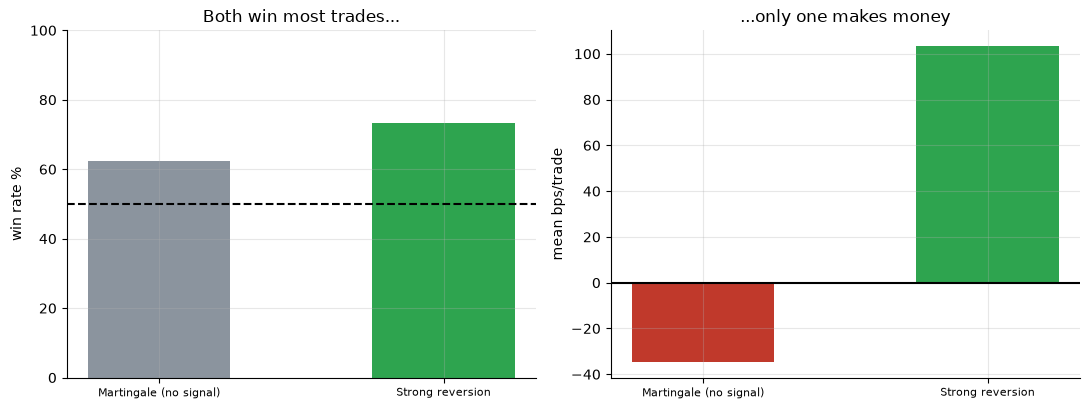

                  tape  win%  mean_bps  skew     t
Martingale (no signal) 62.33    -34.56 -1.65 -1.15
      Strong reversion 73.44    103.35 -1.07  5.07


In [4]:
rows = []
for rev, lab in [(0.0,'Martingale (no signal)'), (0.5,'Strong reversion')]:
    b, _ = data.synthetic_daily(n_days=8000, reversion=rev, seed=301)
    sig = st.triple_rsi_entries(b, trend_sma=None)
    s = st.summarize(st.run_trades(b, sig, rsi_exit=50.0, cost_bps=0, entry='close'),'ret_gross')
    rows.append((lab, s['win_rate']*100, s['mean_bps'], s['skew'], s['tstat']))
dfm = pd.DataFrame(rows, columns=['tape','win%','mean_bps','skew','t'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(dfm['tape'], dfm['win%'], color=[GREY, GREEN], width=.5)
a1.axhline(50, ls='--', c='k'); a1.set_ylim(0,100); a1.set_ylabel('win rate %')
a1.set_title('Both win most trades...'); a1.tick_params(axis='x', labelsize=8)
a2.bar(dfm['tape'], dfm['mean_bps'], color=[RED, GREEN], width=.5)
a2.axhline(0, c='k'); a2.set_ylabel('mean bps/trade')
a2.set_title('...only one makes money'); a2.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()
print(dfm.round(2).to_string(index=False))

> In plain words: the martingale wins **~62%** of trades with a **-35 bps** mean (*t* = -1.15) and skew -1.6. The win-rate is manufactured by the 'sell on the bounce' exit, independent of any edge. On SPY the win-rate is high *and* the mean is real — but the marketed number is the wrong one to quote. **H₅ rejected.**

## 5 · The verdict

- **Signal `REAL`** — SPY gross +132.8 bps/trade, HAC *t* +5.07; next-open +4.22; post-2010 +3.11; pooled +8.28; excess over random +84.9 bps.
- **Tradability `FRAGILE`** — cost-robust (*t* +4.69 at 10 bps) but 3.5 trades/yr and ~7% time in market, so ~+4.7%/yr vs SPY B&H +10.8%/yr. Capacity, not cost.
- **A 90% win-rate money machine? `BUSTED`** — 88% win-rate, but a coin under the same exit clears 62% at a loss; skew -1.6. Win-rate measures the exit, not the edge.

## 6 · Could you trade it? — cost sweep and the capacity wall

The per-trade edge is enormous relative to costs; the binding constraint is how rarely it deploys capital.

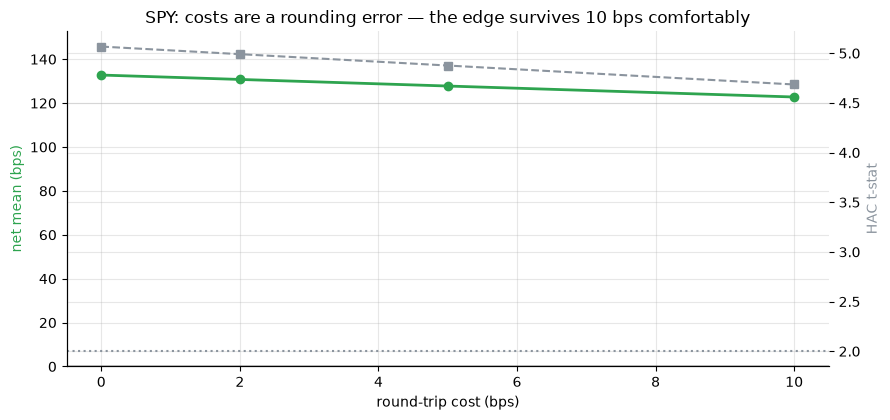

At 10 bps: +122.8 bps/trade, t=+4.69  —  but only 3.5 trades/yr


In [5]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    spy = fetch('SPY'); sig = st.triple_rsi_entries(spy)
    sw = [st.summarize(st.run_trades(spy, sig, rsi_exit=50.0, cost_bps=c, entry='close'),'ret_net') for c in costs]
    means = [s['mean_bps'] for s in sw]; tstats = [s['tstat'] for s in sw]
else:
    means = [132.8,130.8,127.8,122.8]
    tstats = [5.07,4.99,4.88,4.69]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, means, 'o-', c=GREEN, lw=2, label='net mean (bps)')
ax2 = ax.twinx(); ax2.plot(costs, tstats, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=GREEN)
ax.set_ylim(0, max(means)*1.15); ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('SPY: costs are a rounding error — the edge survives 10 bps comfortably')
plt.tight_layout(); plt.show()
print(f'At 10 bps: +122.8 bps/trade, t=+4.69  —  but only 3.5 trades/yr')

> In plain words: contrast the desk's mirages, where the gross was already negative. Here the gross is huge and survives any realistic cost — yet the strategy contributes only ~+4.7%/yr because it is in the market ~7% of the time. A real edge, structurally unable to fill a portfolio: the definition of **fragile**.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful detector, or does it always print the same number? Plant a short-term AR(1) anti-persistence and sweep its strength.

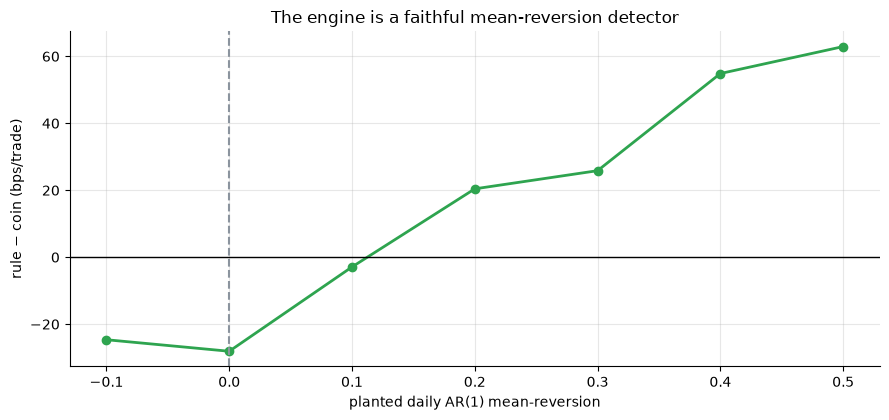

Edge ~0 at the martingale, rising with planted anti-persistence.


In [6]:
revs = [-0.10, 0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
edge = []
for rev in revs:
    b, _ = data.synthetic_daily(n_days=8000, reversion=rev, seed=301)
    sig = st.triple_rsi_entries(b, trend_sma=None)
    rule = st.summarize(st.run_trades(b, sig, rsi_exit=50.0, cost_bps=0, entry='close'),'ret_gross')['mean_bps']
    rand = st.summarize(st.run_trades(b, sig, rsi_exit=50.0, cost_bps=0, entry='close',
        random_dirs=st.random_directions(int(sig.sum()), seed=1)),'ret_gross')['mean_bps']
    edge.append(rule - rand)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(revs, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted daily AR(1) mean-reversion'); ax.set_ylabel('rule − coin (bps/trade)')
ax.set_title('The engine is a faithful mean-reversion detector')
plt.tight_layout(); plt.show()
print('Edge ~0 at the martingale, rising with planted anti-persistence.')

The rule's advantage is monotone in the planted anti-persistence and ~0 at the martingale — so the engine is faithful, and the real-tape result is a statement about **the market**: short-term mean reversion in index ETFs is real, the Triple-RSI is one (over-conditioned) way to harvest it, and the '90% win rate' is the least informative thing about it.

For a denser implementation of the same edge, see [Study 75 — Knee-Jerk](../../75-knee-jerk/) (RSI(2), ~24 trades/yr); for the win-rate illusion in its pure form, [Study 72 — Loaded-Dice](../../72-loaded-dice/).